In [3]:
import os
import numpy as np
from PIL import Image
import cv2
from tqdm import tqdm
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from skimage.feature import local_binary_pattern
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from joblib import dump
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [58]:
base_dir = r"D:\PHD Project\Balanced"  
classes = ["major-damage", "minor-damage", "unknown"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)

✅ Using device: cuda


In [59]:
def load_all_images(base_dir, classes, img_size=(128, 128)):
    X, y = [], []
    for label_idx, cls in enumerate(classes):
        class_folder = os.path.join(base_dir, cls, "images")  # ✅ now goes into 'images'
        if not os.path.exists(class_folder):
            print(f"⚠️ Folder not found: {class_folder}")
            continue
        for file in tqdm(os.listdir(class_folder), desc=f"Loading {cls}"):
            img_path = os.path.join(class_folder, file)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, img_size)
                X.append(img)
                y.append(label_idx)
    return np.array(X), np.array(y)

In [60]:
# 4. Load All Data
# ==============================
print("📥 Loading all images...")
X, y = load_all_images(base_dir, classes)
print(f"✅ Loaded {len(X)} total images.")

📥 Loading all images...


Loading unknown: 100%|██████████| 387/387 [00:00<00:00, 2204.13it/s]

✅ Loaded 1161 total images.


In [61]:
print("✂️ Splitting data into Train / Test...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"📂 TRAIN: {len(X_train)} | TEST: {len(X_test)}")

✂️ Splitting data into Train / Test...
📂 TRAIN: 928 | TEST: 233


In [62]:
# 6. Color Histogram Extraction
# ==============================
def extract_color_histogram(images, bins=(8, 8, 8)):
    features = []
    for img in tqdm(images, desc="Extracting Color Histograms"):
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 256, 0, 256, 0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        features.append(hist)
    return np.array(features)

print("\n🎨 Extracting color histogram features...")
X_train_f = extract_color_histogram(X_train)
X_test_f = extract_color_histogram(X_test)


🎨 Extracting color histogram features...


Extracting Color Histograms: 100%|██████████| 233/233 [00:00<00:00, 6595.97it/s]


In [65]:
# ---------- Decision Tree ----------
print("\n🌲 Training Decision Tree Classifier...")
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_f, y_train)

# Predictions
y_train_pred_dt = dt.predict(X_train_f)
y_test_pred_dt = dt.predict(X_test_f)

# Accuracy
train_acc_dt = accuracy_score(y_train, y_train_pred_dt)
test_acc_dt = accuracy_score(y_test, y_test_pred_dt)

print("\n📊 Decision Tree Results:")
print(f"✅ Training Accuracy: {train_acc_dt:.4f}")
print(f"✅ Testing Accuracy: {test_acc_dt:.4f}")

print("\n--- 🧾 Classification Report (Training) ---")
print(classification_report(y_train, y_train_pred_dt, target_names=classes))

print("\n--- 🧾 Classification Report (Testing) ---")
print(classification_report(y_test, y_test_pred_dt, target_names=classes))


🌲 Training Decision Tree Classifier...

📊 Decision Tree Results:
✅ Training Accuracy: 1.0000
✅ Testing Accuracy: 0.6910

--- 🧾 Classification Report (Training) ---
              precision    recall  f1-score   support

major-damage       1.00      1.00      1.00       310
minor-damage       1.00      1.00      1.00       309
     unknown       1.00      1.00      1.00       309

    accuracy                           1.00       928
   macro avg       1.00      1.00      1.00       928
weighted avg       1.00      1.00      1.00       928


--- 🧾 Classification Report (Testing) ---
              precision    recall  f1-score   support

major-damage       0.71      0.71      0.71        77
minor-damage       0.62      0.63      0.62        78
     unknown       0.74      0.73      0.74        78

    accuracy                           0.69       233
   macro avg       0.69      0.69      0.69       233
weighted avg       0.69      0.69      0.69       233



In [66]:
# ---------- Random Forest ----------
print("\n🌳 Training Random Forest Classifier...")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_f, y_train)

# Predictions
y_train_pred_rf = rf.predict(X_train_f)
y_test_pred_rf = rf.predict(X_test_f)

# Accuracy
train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
test_acc_rf = accuracy_score(y_test, y_test_pred_rf)

print("\n📊 Random Forest Results:")
print(f"✅ Training Accuracy: {train_acc_rf:.4f}")
print(f"✅ Testing Accuracy: {test_acc_rf:.4f}")

print("\n--- 🧾 Classification Report (Training) ---")
print(classification_report(y_train, y_train_pred_rf, target_names=classes))

print("\n--- 🧾 Classification Report (Testing) ---")
print(classification_report(y_test, y_test_pred_rf, target_names=classes))


🌳 Training Random Forest Classifier...

📊 Random Forest Results:
✅ Training Accuracy: 1.0000
✅ Testing Accuracy: 0.7253

--- 🧾 Classification Report (Training) ---
              precision    recall  f1-score   support

major-damage       1.00      1.00      1.00       310
minor-damage       1.00      1.00      1.00       309
     unknown       1.00      1.00      1.00       309

    accuracy                           1.00       928
   macro avg       1.00      1.00      1.00       928
weighted avg       1.00      1.00      1.00       928


--- 🧾 Classification Report (Testing) ---
              precision    recall  f1-score   support

major-damage       0.73      0.74      0.74        77
minor-damage       0.70      0.59      0.64        78
     unknown       0.74      0.85      0.79        78

    accuracy                           0.73       233
   macro avg       0.72      0.73      0.72       233
weighted avg       0.72      0.73      0.72       233



In [67]:
# ==============================
# 🌲 Train Random Forest Classifier
# ==============================
print("\n🌲 Training Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_f, y_train)

# ==============================
# 🎯 Evaluate
# ==============================
y_train_pred_rf = rf_model.predict(X_train_f)
y_test_pred_rf = rf_model.predict(X_test_f)

train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
test_acc_rf = accuracy_score(y_test, y_test_pred_rf)

print("\n📊 Random Forest Results:")
print(f"✅ Training Accuracy: {train_acc_rf:.4f}")
print(f"✅ Testing Accuracy:  {test_acc_rf:.4f}")

print("\n--- 🧾 Classification Report (Training) ---")
print(classification_report(y_train, y_train_pred_rf, target_names=classes))

print("\n--- 🧾 Classification Report (Testing) ---")
print(classification_report(y_test, y_test_pred_rf, target_names=classes))


🌲 Training Random Forest Classifier...

📊 Random Forest Results:
✅ Training Accuracy: 0.9989
✅ Testing Accuracy:  0.7039

--- 🧾 Classification Report (Training) ---
              precision    recall  f1-score   support

major-damage       1.00      1.00      1.00       310
minor-damage       1.00      1.00      1.00       309
     unknown       1.00      1.00      1.00       309

    accuracy                           1.00       928
   macro avg       1.00      1.00      1.00       928
weighted avg       1.00      1.00      1.00       928


--- 🧾 Classification Report (Testing) ---
              precision    recall  f1-score   support

major-damage       0.67      0.75      0.71        77
minor-damage       0.72      0.50      0.59        78
     unknown       0.72      0.86      0.78        78

    accuracy                           0.70       233
   macro avg       0.71      0.70      0.70       233
weighted avg       0.71      0.70      0.70       233



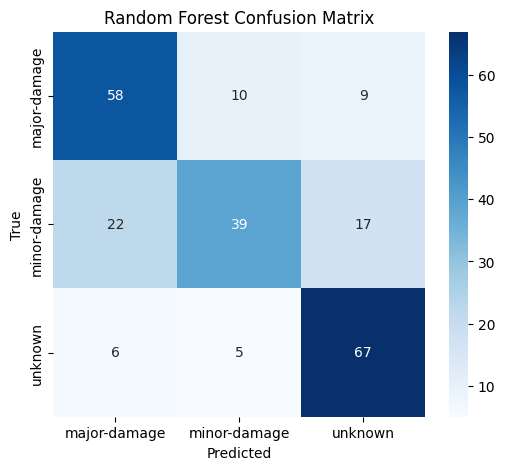

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [4]:
# ==============================
# 1. Import Libraries
# ==============================
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from skimage.feature import hog

# ==============================
# 2. Dataset Path (Before Splitting)
# ==============================
base_dir = r"D:\PHD Project\Balanced"
classes = ["major-damage", "minor-damage", "unknown"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)

# ==============================
# 3. Load Images Function
# ==============================
def load_all_images(base_dir, classes, img_size=(128, 128)):
    X, y = [], []
    for label_idx, cls in enumerate(classes):
        class_folder = os.path.join(base_dir, cls, "images")
        for file in tqdm(os.listdir(class_folder), desc=f"Loading {cls}"):
            img_path = os.path.join(class_folder, file)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, img_size)
                X.append(img)
                y.append(label_idx)
    return np.array(X), np.array(y)

# ==============================
# 4. Load and Split Data
# ==============================
X, y = load_all_images(base_dir, classes)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"📂 TRAIN: {len(X_train)} | TEST: {len(X_test)}")

# ==============================
# 5. HOG Feature Extraction
# ==============================
def extract_hog_features(images):
    features = []
    for img in tqdm(images, desc="Extracting HOG Features"):
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        hog_features = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            transform_sqrt=True,
            feature_vector=True
        )
        features.append(hog_features)
    return np.array(features)

X_train_f = extract_hog_features(X_train)
X_test_f = extract_hog_features(X_test)

print(f"✅ HOG features extracted: {X_train_f.shape[1]} dimensions per image")

# ==============================
# 6. Train & Evaluate Models
# ==============================
def train_and_evaluate(model, name):
    print(f"\n🌲 Training {name} Classifier...")
    model.fit(X_train_f, y_train)

    y_train_pred = model.predict(X_train_f)
    y_test_pred = model.predict(X_test_f)

    print(f"\n📊 {name} Results:")
    print(f"✅ Training Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"✅ Testing Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")

    print("\n--- 🧾 Classification Report (Training) ---")
    print(classification_report(y_train, y_train_pred, target_names=classes))
    print("\n--- 🧾 Classification Report (Testing) ---")
    print(classification_report(y_test, y_test_pred, target_names=classes))
    return y_test_pred

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
y_pred_dt = train_and_evaluate(dt_model, "Decision Tree")

# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
y_pred_rf = train_and_evaluate(rf_model, "Random Forest")

✅ Using device: cuda


Loading unknown: 100%|██████████| 387/387 [00:03<00:00, 100.80it/s]


📂 TRAIN: 928 | TEST: 233


Extracting HOG Features: 100%|██████████| 233/233 [00:00<00:00, 292.97it/s]


✅ HOG features extracted: 8100 dimensions per image

🌲 Training Decision Tree Classifier...

📊 Decision Tree Results:
✅ Training Accuracy: 1.0000
✅ Testing Accuracy:  0.5193

--- 🧾 Classification Report (Training) ---
              precision    recall  f1-score   support

major-damage       1.00      1.00      1.00       310
minor-damage       1.00      1.00      1.00       309
     unknown       1.00      1.00      1.00       309

    accuracy                           1.00       928
   macro avg       1.00      1.00      1.00       928
weighted avg       1.00      1.00      1.00       928


--- 🧾 Classification Report (Testing) ---
              precision    recall  f1-score   support

major-damage       0.49      0.48      0.49        77
minor-damage       0.49      0.45      0.47        78
     unknown       0.57      0.63      0.60        78

    accuracy                           0.52       233
   macro avg       0.52      0.52      0.52       233
weighted avg       0.52      0.5